# Ambition x CCS matrix — results

Four GCAM ambition scenarios (SSP-RCP pairs: SSP1-1.9, SSP1-2.6, SSP2-3.7, SSP2-4.5) crossed with
four captive-power capture regimes (unlimited, none, low, high). Smelter side. Each ambition
scenario supplies its **own GCAM demand, grid intensity and carbon budget**, so the budget differs
by column; the CCS regime does not change the budget.

Emissions are `CO2 Scope1 + CO2 Scope2` as reported (both already net of deployed capture; the
separate `CO2 Scope1 captured` column is a per-tonne input factor, not realised capture, so it is
not used here). Reads the saved runs directly, independent of `common.py`. Interim stand-in GCAM
runs — method validation, not findings.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RUNS = Path("..") / ".." / "runs"          # notebooks/analysis -> scenarios/runs
AMBITION = ["SSP1_1p9", "SSP1_2p6", "SSP2_3p7", "SSP2_4p5"]     # GCAM SSP-RCP, most->least ambitious
AMB_LABEL = {"SSP1_1p9": "SSP1-1.9", "SSP1_2p6": "SSP1-2.6",
             "SSP2_3p7": "SSP2-3.7", "SSP2_4p5": "SSP2-4.5"}
CCS   = ["unlimited", "none", "low", "high"]
YEARS = range(2020, 2051)

def interface(cell):
    f = next((RUNS / cell / "smelter" / "final").glob("interface_outputs_*.csv"))
    return pd.read_csv(f)

def annual_emissions(cell):
    d = interface(cell)
    e = d[d.parameter.isin(["CO2 Scope1", "CO2 Scope2"])]
    return e.groupby("year").value.sum()          # Mt CO2/yr

def budget(cell):                                  # Gt CO2/yr, indexed by year
    b = pd.read_csv(RUNS / cell / "smelter" / "inputs_used" / "carbon_budget.csv")
    return b.set_index("year").annual_limit

def mix_2050(cell):                                # Mt by power source in 2050
    d = interface(cell)
    v = d[(d.parameter == "Annual production volume") & (d.year == 2050)].copy()
    v = v[v.technology.astype(str).str.contains(" + ", regex=False)]
    v["power"] = v.technology.astype(str).str.split(" + ", n=1, regex=False).str[1]
    v["anode"] = v.technology.astype(str).str.split(" + ", n=1, regex=False).str[0]
    return v

print("runs found:", sum((RUNS / f"{a}_{c}").exists() for a in AMBITION for c in CCS), "of 16")

runs found: 16 of 16


## 1. Cumulative emissions and gap to each scenario's budget

In [2]:
rows = []
for a in AMBITION:
    for c in CCS:
        cell = f"{a}_{c}"
        cum = annual_emissions(cell).loc[2020:2050].sum() / 1000     # Mt -> Gt
        bcum = budget(cell).loc[2020:2050].sum()                     # Gt (this scenario's budget)
        rows.append(dict(ambition=AMB_LABEL[a], ccs=c, cum_Gt=cum, budget_Gt=bcum,
                         gap_Gt=cum - bcum, gap_pct=100 * (cum - bcum) / bcum))
summary = pd.DataFrame(rows)
labels = [AMB_LABEL[a] for a in AMBITION]

cum_tab = summary.pivot(index="ambition", columns="ccs", values="cum_Gt").reindex(labels, columns=CCS)
bud_tab = summary.pivot(index="ambition", columns="ccs", values="budget_Gt").reindex(labels, columns=CCS)
gap_tab = summary.pivot(index="ambition", columns="ccs", values="gap_pct").reindex(labels, columns=CCS)
print("Cumulative smelting emissions 2020-2050 (Gt)\n"); display(cum_tab.round(2))
print("\nGCAM budget (Gt) — differs by ambition scenario\n"); display(bud_tab.round(2))
print("\nGap to budget (%)"); display(gap_tab.round(1))

Cumulative smelting emissions 2020-2050 (Gt)



ccs,unlimited,none,low,high
ambition,,,,
SSP1-1.9,10.41,10.52,10.55,10.48
SSP1-2.6,13.14,12.95,13.08,13.19
SSP2-3.7,17.92,18.07,18.00,18.12
SSP2-4.5,19.72,19.77,19.76,19.89



GCAM budget (Gt) — differs by ambition scenario



ccs,unlimited,none,low,high
ambition,,,,
SSP1-1.9,10.24,10.24,10.24,10.24
SSP1-2.6,13.03,13.03,13.03,13.03
SSP2-3.7,17.87,17.87,17.87,17.87
SSP2-4.5,19.61,19.61,19.61,19.61



Gap to budget (%)


ccs,unlimited,none,low,high
ambition,,,,
SSP1-1.9,1.6,2.7,3.0,2.4
SSP1-2.6,0.9,-0.6,0.4,1.3
SSP2-3.7,0.3,1.1,0.7,1.4
SSP2-4.5,0.5,0.8,0.8,1.4


Read across a row for the capture effect at fixed ambition, down a column for the ambition effect
at fixed capture. Each ambition scenario carries its own GCAM demand, grid and budget, so the
budget tightens down the column (SSP1-1.9 most, SSP2-4.5 least). Interim stand-in GCAM runs.

## 2. Annual emissions against the budget

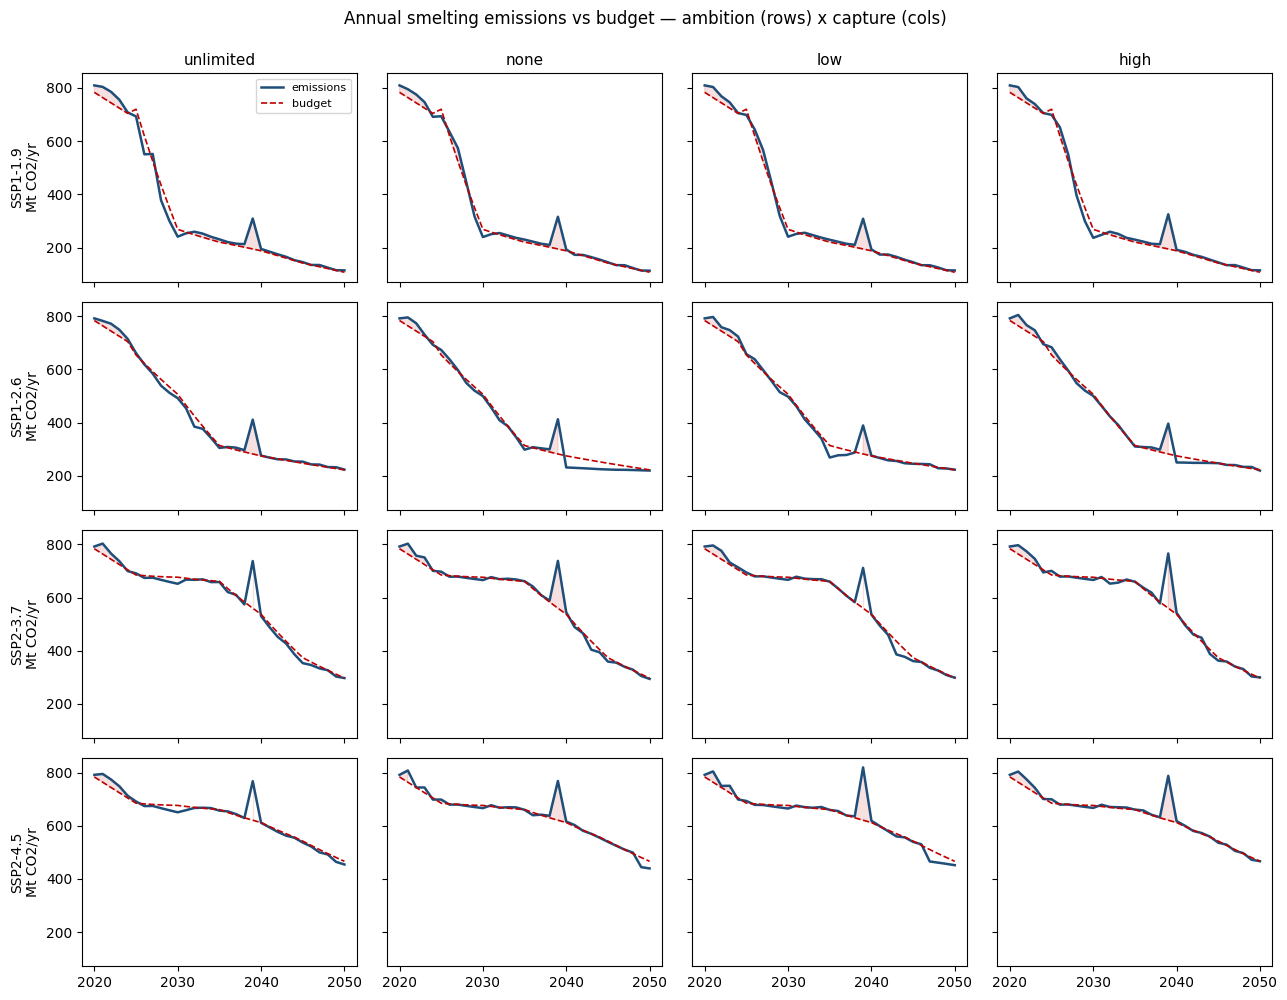

In [3]:
fig, axes = plt.subplots(len(AMBITION), len(CCS), figsize=(13, 10), sharex=True, sharey=True)
yrs = list(YEARS)
for i, a in enumerate(AMBITION):
    for j, c in enumerate(CCS):
        ax = axes[i][j]
        cell = f"{a}_{c}"
        e = annual_emissions(cell).reindex(yrs)
        b = budget(cell).reindex(yrs) * 1000                        # Gt -> Mt
        ax.plot(yrs, e.values, color="#1f4e79", lw=1.8, label="emissions")
        ax.plot(yrs, b.values, color="#c00000", lw=1.2, ls="--", label="budget")
        ax.fill_between(yrs, b.values, e.values, where=(e.values > b.values),
                        color="#c00000", alpha=0.12)
        if i == 0: ax.set_title(c, fontsize=11)
        if j == 0: ax.set_ylabel(AMB_LABEL[a] + "\nMt CO2/yr", fontsize=10)
axes[0][0].legend(fontsize=8, loc="upper right")
fig.suptitle("Annual smelting emissions vs budget — ambition (rows) x capture (cols)", y=0.995)
fig.tight_layout(); plt.show()

## 3. 2050 power-source mix

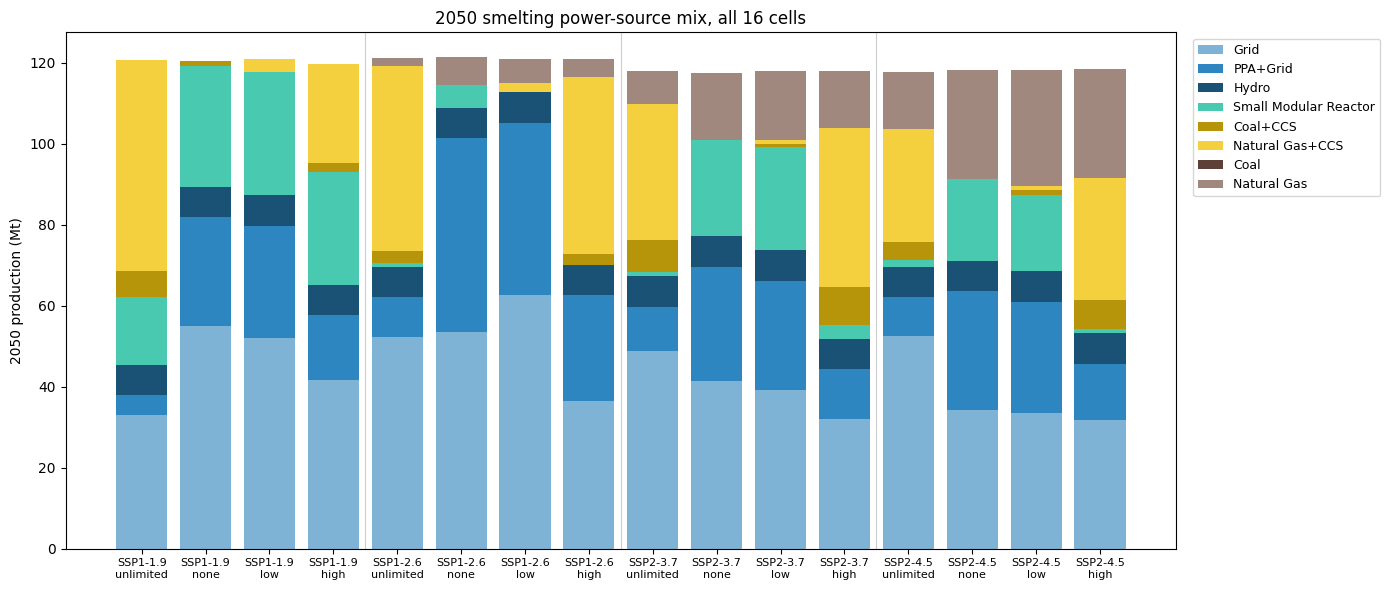

In [4]:
# Order power sources: clean captive, then power-CCS, then unabated fossil
ORDER = ["Grid", "PPA+Grid", "Hydro", "Small Modular Reactor",
         "Coal+CCS", "Natural Gas+CCS", "Coal", "Natural Gas"]
COLORS = {"Grid": "#7fb3d5", "PPA+Grid": "#2e86c1", "Hydro": "#1a5276",
          "Small Modular Reactor": "#48c9b0", "Coal+CCS": "#b7950b",
          "Natural Gas+CCS": "#f4d03f", "Coal": "#5d4037", "Natural Gas": "#a1887f"}

data = {}
for a in AMBITION:
    for c in CCS:
        m = mix_2050(f"{a}_{c}").groupby("power").value.sum()
        data[f"{AMB_LABEL[a]}\n{c}"] = m
mix = pd.DataFrame(data).reindex(ORDER).fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(mix.shape[1])
for pw in ORDER:
    ax.bar(mix.columns, mix.loc[pw].values, bottom=bottom, label=pw, color=COLORS.get(pw))
    bottom += mix.loc[pw].values
ax.set_ylabel("2050 production (Mt)")
ax.set_title("2050 smelting power-source mix, all 16 cells")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
for x in (3.5, 7.5, 11.5): ax.axvline(x, color="0.8", lw=0.8)
plt.xticks(rotation=0, fontsize=8); fig.tight_layout(); plt.show()

In [5]:
# Category summary: inert-anode share, clean-power Mt, power-CCS Mt, unabated captive-fossil Mt
def cats(cell):
    v = mix_2050(cell); tot = v.value.sum()
    inert = v[v.anode.str.startswith("Inert")].value.sum()
    clean = v[v.power.isin(["Grid", "PPA+Grid", "Hydro", "Small Modular Reactor"])].value.sum()
    ccsp  = v[v.power.str.contains("CCS")].value.sum()
    fossil = v[v.power.isin(["Coal", "Natural Gas"])].value.sum()
    return dict(inert_anode_pct=round(100 * inert / tot), clean_Mt=round(clean, 1),
                power_CCS_Mt=round(ccsp, 1), unabated_fossil_Mt=round(fossil, 1))
cat = pd.DataFrame({f"{a}_{c}": cats(f"{a}_{c}") for a in AMBITION for c in CCS}).T
display(cat)

,inert_anode_pct,clean_Mt,power_CCS_Mt,unabated_fossil_Mt
SSP1_1p9_unlimited,81.0,62.2,58.4,0.0
SSP1_1p9_none,71.0,119.2,1.2,0.0
SSP1_1p9_low,71.0,117.8,3.1,0.0
SSP1_1p9_high,75.0,93.1,26.8,0.0
SSP1_2p6_unlimited,46.0,70.6,48.7,1.9
SSP1_2p6_none,50.0,114.6,0.0,6.9
SSP1_2p6_low,47.0,112.7,2.2,5.9
SSP1_2p6_high,52.0,70.1,46.5,4.5
SSP2_3p7_unlimited,43.0,68.2,41.7,8.1
SSP2_3p7_none,55.0,101.0,0.0,16.4
